# 02. Unnamed 인덱스 분리 · 독립변수 상관관계 히트맵 · 왜도(Skew) 보정

01번 노트북(`01_baseline_linear_regression.ipynb`)에서 이어지는 전처리/EDA 보강 노트북입니다.
이 노트북에서는 **모델을 새로 학습하지 않고**, 다음 세 가지만 다룹니다.

1. `Unnamed: 0`(원본 CSV 행 번호) 컬럼을 분석용 데이터에서 완전히 제외하되, 어떤
   배정번호가 원본 파일의 몇 번째 행 범위에 있었는지는 별도 참조 파일로 남겨둡니다.
2. 다중공선성 제거 **전/후** 독립변수끼리의 상관관계를 히트맵으로 비교합니다.
3. 치우친(skewed) 독립변수를 진단하고, Yeo-Johnson 파워변환으로 정규분포에
   가깝게 보정합니다. (누수 방지를 위해 train 데이터에만 fit)

> 모델 재학습(개선된 피처로 LinearRegression/SGDRegressor 다시 학습, 01과 성능 비교)은
> 다음 `03` 노트북에서 진행합니다.

## 이 노트북이 여는 데이터

01 노트북이 이미 `data_processed/df_total.csv`(136행, 배정번호 단위 집계 + 라벨 병합 완료본)를
만들어 두었기 때문에, 이 노트북에서는 481MB/502MB짜리 원본 CSV(`raw_total_data.csv`,
`품질전처리후데이터.csv`)를 다시 읽지 않고 `df_total.csv`만 불러와 이어서 작업합니다.
(따라서 이 노트북을 실행하려면 반드시 01 노트북을 먼저 한 번 실행해 두어야 합니다.)

## 프로젝트 지침 체크

- 파일 형식: `.ipynb` ✅
- 함수 선언 시 설명 주석: `src/training_utils.py`에 추가한 함수 4개
  (`plot_correlation_heatmap`, `check_skewness`, `correct_skew_with_power_transform`,
  `plot_skew_before_after`) 모두 docstring으로 동작 설명 포함 ✅
- 진행상황 표시: 데이터 로딩/저장 단계마다 진행 메시지 출력 ✅
  (이 노트북은 반복 학습 루프가 없어 tqdm 진행률 표시줄은 해당 사항 없음 —
  체크포인트/재개가 필요한 반복 학습은 03 노트북에서 다룹니다.)
- 중단 방지: 매 단계 산출물을 `data_processed/`, `checkpoints/`에 즉시 저장해
  다음 실행/다음 노트북에서 바로 이어 쓸 수 있게 함 ✅
- README / requirements: 이 노트북 추가 내용에 맞춰 `README.md` 갱신,
  신규 라이브러리는 없어 `requirements.txt`는 변경 없음 ✅


## 개정 이력

- **2026-09-16 수정**: Yeo-Johnson 파워변환 과정에서 일부 컬럼이 "조용히 붕괴"하는
  문제를 발견해 수정했다. 자세한 배경은 아래 9절 및 `src/training_utils.py`의
  `correct_skew_with_power_transform()` 함수 docstring 참고. 요약하면 다음과 같다.
    - 좁은 양수 범위(예: 97~100)에 값이 몰려있는 일부 센서 집계 컬럼에서, scipy의
      Yeo-Johnson lambda 최적화가 예외 없이 "성공"하면서도 -3~-7 수준의 극단적인
      lambda를 골라버려, 변환 결과가 전체 train 표본에서 거의 동일한 값(표준편차
      1e-15~1e-16 수준)으로 붕괴하는 현상이 있었다.
    - 이렇게 붕괴된 컬럼은 사실상 상수 컬럼이 되어 회귀식의 절편(intercept)과
      거의 완벽한 공선성을 이루고, 이것이 `01_baseline_linear_regression.ipynb`에서
      관찰된 LinearRegression 계수 폭주(최대 계수 약 1.6×10¹³)의 실제 원인이었다.
      VIF는 "다른 피처와의" 공선성만 측정하므로 이 문제를 잡아내지 못한다
      (04/05 노트북에서 재확인).
    - `correct_skew_with_power_transform()`에 변환 후 표준편차를 확인하는 가드
      (`collapse_std_threshold`, 기본 1e-3)를 추가해, 이렇게 붕괴하는 컬럼은
      "실패"로 분류하고 원본값을 그대로 사용하도록 했다.


In [1]:
# ===== 0. 환경 설정 =====
# - 필요한 라이브러리 불러오기
# - 경고 메시지 숨기기
# - 재현성을 위한 랜덤 시드 고정 (01 노트북과 동일한 값 사용 -> 동일한 train/val/test 분할 재현)
# - 데이터 / 체크포인트 / 그림 저장 경로 설정
# - 한글 폰트(나눔고딕) 설정 (그래프 한글 깨짐 방지)
import os
import sys
import warnings

warnings.filterwarnings(action="ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# src/training_utils.py 를 import 할 수 있도록 경로 추가
sys.path.append(os.path.abspath(os.path.join("..", "src")))
import training_utils as tu

RANDOM_STATE = 42  # 01 노트북과 동일. train_test_split은 (행 수, random_state)가 같으면
                    # 컬럼 구성이 달라져도 동일한 행이 뽑히므로 01과 같은 배정번호가 train/val/test에 배정됩니다.
np.random.seed(RANDOM_STATE)

PROCESSED_DIR = os.path.join("..", "data_processed")
CHECKPOINT_DIR = os.path.join("..", "checkpoints")
FIGURE_DIR = os.path.join("..", "figures")
for d in (PROCESSED_DIR, CHECKPOINT_DIR, FIGURE_DIR):
    os.makedirs(d, exist_ok=True)

sns.set_theme(style="whitegrid")
tu.set_korean_font("NanumGothic")

print("환경 설정 완료. RANDOM_STATE =", RANDOM_STATE)


[한글 폰트] 'NanumGothicOTF' 적용 완료.
환경 설정 완료. RANDOM_STATE = 42


## 1. 01 노트북 산출물(`df_total.csv`) 불러오기

In [2]:
# ===== 1-1. df_total.csv 로드 =====
# 01 노트북 2-4단계에서 저장한, 배정번호 단위로 집계 + 라벨(양품/불량수량, 불량비율) 병합이
# 완료된 데이터다. 이 시점에는 다중공선성 제거를 하기 전이라 Unnamed: 0_min/_max 도 그대로
# 들어있다 (01에서는 Unnamed: 0_max 가 걸러지지 않고 최종 27개 변수에 포함되어 있었다).
df_total_path = os.path.join(PROCESSED_DIR, "df_total.csv")
print(f"'{df_total_path}' 불러오는 중 ...")
df_total = pd.read_csv(df_total_path, encoding="utf-8-sig")
print(f"  -> shape: {df_total.shape}")

unnamed_cols_found = [c for c in df_total.columns if c.startswith("Unnamed")]
print("Unnamed 관련 컬럼:", unnamed_cols_found)
display(df_total.head())


'..\data_processed\df_total.csv' 불러오는 중 ...
  -> shape: (136, 42)
Unnamed 관련 컬럼: ['Unnamed: 0_min', 'Unnamed: 0_max']


,배정번호,양품수량,불량수량,불량비율,Unnamed: 0_min,건조 1존 OP_min,건조 2존 OP_min,건조로 온도 1 Zone_min,건조로 온도 2 Zone_min,세정기_min,...,소입4존 OP_max,소입로 CP 값_max,소입로 온도 1 Zone_max,소입로 온도 2 Zone_max,소입로 온도 3 Zone_max,소입로 온도 4 Zone_max,솔트 컨베이어 온도 1 Zone_max,솔트 컨베이어 온도 2 Zone_max,솔트조 온도 1 Zone_max,솔트조 온도 2 Zone_max
0,102410,15160,3,0.019785,0,55.8907,7.84754,97.8385,98.4388,68.2865,...,80.3567,0.505652,870.536,861.258,860.889,862.014,295.967,288.406,329.293,329.300
1,102585,29892,10,0.033443,7342,55.4900,5.02241,97.9840,98.5958,67.6928,...,81.8909,0.470900,871.084,861.795,860.874,861.513,296.437,290.651,329.343,329.121
2,102930,59616,30,0.050297,20641,53.9100,7.32836,97.7743,98.5116,67.3211,...,78.8885,0.473188,869.805,861.587,861.064,861.865,297.002,289.902,329.443,329.383
3,103142,74730,13,0.017393,47623,55.6307,7.47999,98.3127,98.1810,67.1142,...,80.9559,0.473631,869.918,860.839,860.768,861.752,296.633,290.161,329.380,329.267
4,103675,14979,2,0.013350,79352,52.9816,7.21693,97.7285,98.4935,67.8759,...,81.6436,0.463701,872.031,860.924,861.067,862.106,295.982,287.750,329.261,329.320


## 2. `Unnamed: 0` (원본 행 번호) 정보 분리 저장

`Unnamed: 0`은 실제 측정값이 아니라, `품질전처리후데이터.csv`를 저장할 때 `index=False`
옵션 없이 저장되어 pandas 인덱스가 그대로 컬럼으로 딸려 들어간 것이다 (01 노트북에서 확인).
집계 과정에서 배정번호별 `Unnamed: 0_min` / `Unnamed: 0_max`로 남아 있었고, 01에서는
`Unnamed: 0_max`가 실수로 모델 입력 변수에 그대로 포함되어 있었다.

여기서는 두 컬럼(배정번호별 원본 행 범위)을 **별도 참조 파일**로 저장해 "이 배정번호가
원본 CSV의 몇 번째 행부터 몇 번째 행까지였는지"는 나중에도 추적할 수 있게 하고,
분석/모델링에 쓰는 데이터에서는 완전히 제거한다.

In [3]:
# ===== 2-1. 원본 행 범위 참조 파일 저장 + 분석용 데이터에서 제거 =====
index_ref_path = os.path.join(PROCESSED_DIR, "original_row_range.csv")

original_row_range = df_total[["배정번호", "Unnamed: 0_min", "Unnamed: 0_max"]].rename(
    columns={"Unnamed: 0_min": "원본_행번호_최소", "Unnamed: 0_max": "원본_행번호_최대"}
)
original_row_range.to_csv(index_ref_path, index=False, encoding="utf-8-sig")
print(f"원본 행 번호 참조 파일 저장 완료 -> {index_ref_path}  ({len(original_row_range)}개 배정번호)")
display(original_row_range.head())

df_total_clean = df_total.drop(columns=["Unnamed: 0_min", "Unnamed: 0_max"])
print(f"\n분석용 데이터에서 Unnamed 관련 컬럼 제거 완료. shape: {df_total.shape} -> {df_total_clean.shape}")


원본 행 번호 참조 파일 저장 완료 -> ..\data_processed\original_row_range.csv  (136개 배정번호)


,배정번호,원본_행번호_최소,원본_행번호_최대
0,102410,0,7341
1,102585,7342,20640
2,102930,20641,47622
3,103142,47623,79351
4,103675,79352,85569



분석용 데이터에서 Unnamed 관련 컬럼 제거 완료. shape: (136, 42) -> (136, 40)


## 3. 독립변수(X) / 종속변수(y) 분리

In [4]:
# ===== 3-1. 독립변수(X) / 종속변수(y) 분리 =====
# 배정번호(식별자), 양품수량/불량수량(불량비율 계산에 이미 사용됨), 불량비율(목표변수)은
# 독립변수에서 제외한다. (01과 동일한 규칙 + Unnamed 관련 컬럼은 이미 위에서 제거됨)
X_full = df_total_clean.drop(columns=["배정번호", "양품수량", "불량수량", "불량비율"])
y_full = df_total_clean["불량비율"]

print("독립변수 개수 (Unnamed 제거 후):", X_full.shape[1], " (01에서는 38개였음, 2개 감소)")


독립변수 개수 (Unnamed 제거 후): 36  (01에서는 38개였음, 2개 감소)


## 4. 독립변수 간 상관관계 히트맵 (다중공선성 제거 **전**)

01 노트북의 히트맵은 라벨(불량비율 등)까지 포함한 전체 변수 히트맵이었다. 여기서는
**독립변수(X_full)끼리만** 상관관계를 봐서, 이후 진행할 다중공선성 제거가 실제로 어떤
변수쌍들을 대상으로 하는지 시각적으로 먼저 확인한다.

In [5]:
# ===== 4-1. 제거 전 히트맵 =====
fig = tu.plot_correlation_heatmap(X_full, title="독립변수 간 상관관계 히트맵 (다중공선성 제거 전)")
fig.savefig(os.path.join(FIGURE_DIR, "10_X_correlation_heatmap_before.png"), dpi=150)
plt.show()

# 상관계수 절댓값 0.8 이상인 변수쌍 목록 (이후 제거 대상이 될 쌍들을 미리 확인)
corr_abs = X_full.corr().abs()
np.fill_diagonal(corr_abs.values, 0.0)
pairs = (
    corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
high_corr_pairs = pairs[pairs >= 0.8].reset_index()
high_corr_pairs.columns = ["변수1", "변수2", "상관계수"]
print(f"|상관계수| >= 0.8 인 변수쌍: {len(high_corr_pairs)}개")
display(high_corr_pairs)


<Figure size 1400x1200 with 2 Axes>

|상관계수| >= 0.8 인 변수쌍: 17개


,변수1,변수2,상관계수
0,솔트조 온도 1 Zone_min,솔트조 온도 1 Zone_max,0.961256
1,소입4존 OP_min,소입로 온도 4 Zone_max,0.953263
2,솔트조 온도 2 Zone_min,솔트조 온도 2 Zone_max,0.951509
3,솔트조 온도 1 Zone_max,솔트조 온도 2 Zone_max,0.944941
4,솔트조 온도 1 Zone_min,솔트조 온도 2 Zone_min,0.931748
5,소입3존 OP_min,소입로 온도 4 Zone_max,0.924104
6,소입로 온도 3 Zone_max,소입로 온도 4 Zone_max,0.923058
7,솔트조 온도 1 Zone_min,솔트조 온도 2 Zone_max,0.916071
8,소입3존 OP_min,소입4존 OP_min,0.904961
9,솔트조 온도 2 Zone_min,솔트조 온도 1 Zone_max,0.886490


## 5. 다중공선성 제거 (상관계수 |r| >= 0.8)

In [6]:
# ===== 5-1. 다중공선성이 높은 변수 제거 =====
# 01과 동일한 함수/임계값(0.8)을 사용한다. Unnamed 관련 컬럼이 빠진 채로 계산되므로
# 01의 제거 로그(11개 제거, 27개 남음)와는 결과가 달라질 수 있다.
X_reduced, drop_log = tu.remove_multicollinear_features(X_full, threshold=0.8)

print(f"제거된 변수 수: {len(drop_log)} / 남은 변수 수: {X_reduced.shape[1]}")
print()
print("=== 제거 로그 (제거된 변수, 남긴 변수, 상관계수) ===")
for row in drop_log:
    print(f"  - {row['dropped']!r} 제거 (↔ {row['kept']!r}, r={row['correlation']:.3f})")


제거된 변수 수: 10 / 남은 변수 수: 26

=== 제거 로그 (제거된 변수, 남긴 변수, 상관계수) ===
  - '솔트조 온도 1 Zone_max' 제거 (↔ '솔트조 온도 1 Zone_min', r=0.961)
  - '소입4존 OP_min' 제거 (↔ '소입로 온도 4 Zone_max', r=0.953)
  - '솔트조 온도 2 Zone_min' 제거 (↔ '솔트조 온도 2 Zone_max', r=0.952)
  - '소입3존 OP_min' 제거 (↔ '소입로 온도 4 Zone_max', r=0.924)
  - '소입로 온도 3 Zone_max' 제거 (↔ '소입로 온도 4 Zone_max', r=0.923)
  - '솔트조 온도 2 Zone_max' 제거 (↔ '솔트조 온도 1 Zone_min', r=0.916)
  - '소입1존 OP_min' 제거 (↔ '솔트 컨베이어 온도 2 Zone_min', r=0.868)
  - '소입로 온도 2 Zone_min' 제거 (↔ '소입로 온도 1 Zone_min', r=0.862)
  - '솔트 컨베이어 온도 2 Zone_min' 제거 (↔ '솔트 컨베이어 온도 1 Zone_min', r=0.840)
  - '건조로 온도 1 Zone_max' 제거 (↔ '건조로 온도 2 Zone_max', r=0.801)


## 6. 독립변수 간 상관관계 히트맵 (다중공선성 제거 **후**, 확인용)

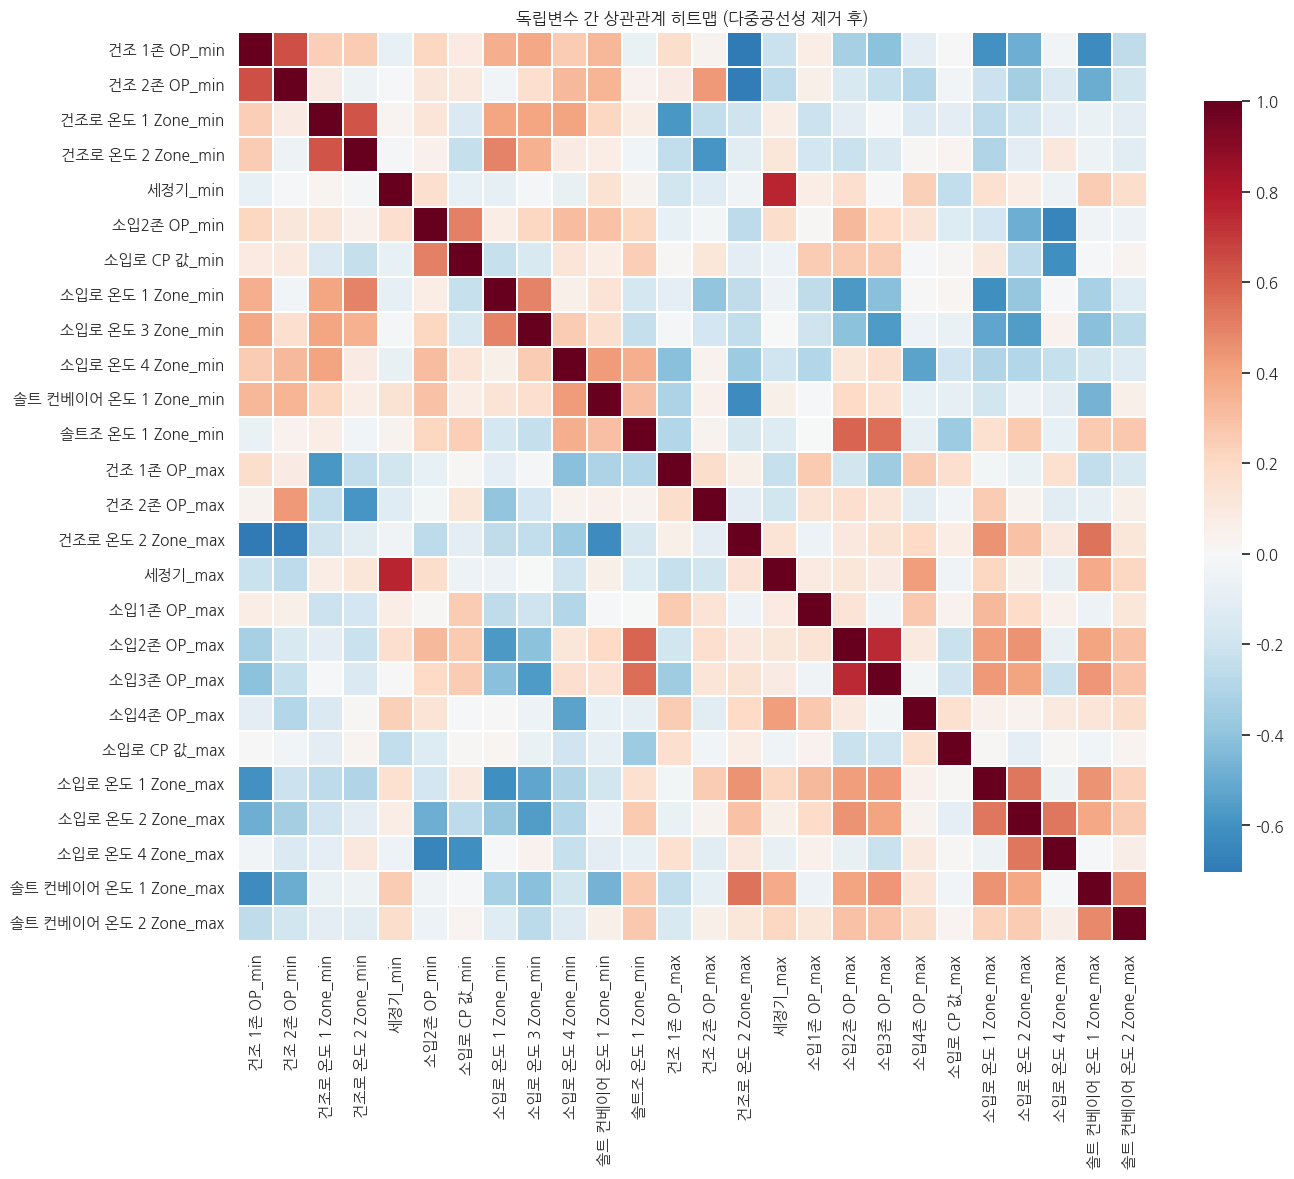

제거 후 남아있는 최대 상관계수(절댓값): 0.754  (0.8 미만이어야 정상)


In [7]:
# ===== 6-1. 제거 후 히트맵 =====
fig = tu.plot_correlation_heatmap(X_reduced, title="독립변수 간 상관관계 히트맵 (다중공선성 제거 후)")
fig.savefig(os.path.join(FIGURE_DIR, "11_X_correlation_heatmap_after.png"), dpi=150)
plt.show()

remaining_max_corr = X_reduced.corr().abs()
np.fill_diagonal(remaining_max_corr.values, 0.0)
print(f"제거 후 남아있는 최대 상관계수(절댓값): {remaining_max_corr.values.max():.3f}  (0.8 미만이어야 정상)")


## 7. Train : Val : Test = 8 : 1 : 1 분할

01과 동일한 `random_state=42`를 사용하므로, 행 수(136개)가 같다면 01과 동일한
배정번호들이 train/val/test로 나뉜다. **Test 세트는 이 노트북에서 모델을 학습하지
않으므로 열어보지 않으며, 왜도 보정 단계에서도 train에만 fit 하고 val/test는
transform만 적용한다.**

In [8]:
# ===== 7-1. 8:1:1 분할 =====
split = tu.split_train_val_test(X_reduced, y_full, ratios=(0.8, 0.1, 0.1), random_state=RANDOM_STATE)
X_train, X_val, X_test = split["X_train"], split["X_val"], split["X_test"]
y_train, y_val, y_test = split["y_train"], split["y_val"], split["y_test"]

print(f"train: {X_train.shape[0]}개  ({X_train.shape[0] / len(df_total_clean):.1%})")
print(f"val  : {X_val.shape[0]}개  ({X_val.shape[0] / len(df_total_clean):.1%})")
print(f"test : {X_test.shape[0]}개  ({X_test.shape[0] / len(df_total_clean):.1%})  <- 이 노트북에서는 학습에 사용하지 않음")


train: 108개  (79.4%)
val  : 14개  (10.3%)
test : 14개  (10.3%)  <- 이 노트북에서는 학습에 사용하지 않음


## 8. 왜도(Skew) 진단 (train 기준)

`X_train`의 각 변수 분포가 얼마나 좌우 비대칭인지 확인한다. **반드시 train 데이터로만
계산**해서 val/test 정보가 전처리 설계에 섞여 들어가는 것(데이터 누수)을 막는다.

,column,skew,abs_skew,is_skewed
0,소입1존 OP_max,-10.392305,10.392305,True
1,소입로 온도 4 Zone_max,9.921675,9.921675,True
2,소입로 CP 값_max,9.613812,9.613812,True
3,솔트 컨베이어 온도 1 Zone_min,7.254046,7.254046,True
4,솔트 컨베이어 온도 1 Zone_max,-6.154958,6.154958,True
5,건조로 온도 2 Zone_max,-4.816178,4.816178,True
6,소입로 CP 값_min,-4.617347,4.617347,True
7,소입2존 OP_min,-3.097132,3.097132,True
8,솔트조 온도 1 Zone_min,-3.000006,3.000006,True
9,건조 1존 OP_min,2.268558,2.268558,True



치우친(|skew| > 0.5) 변수: 20개 / 전체 26개


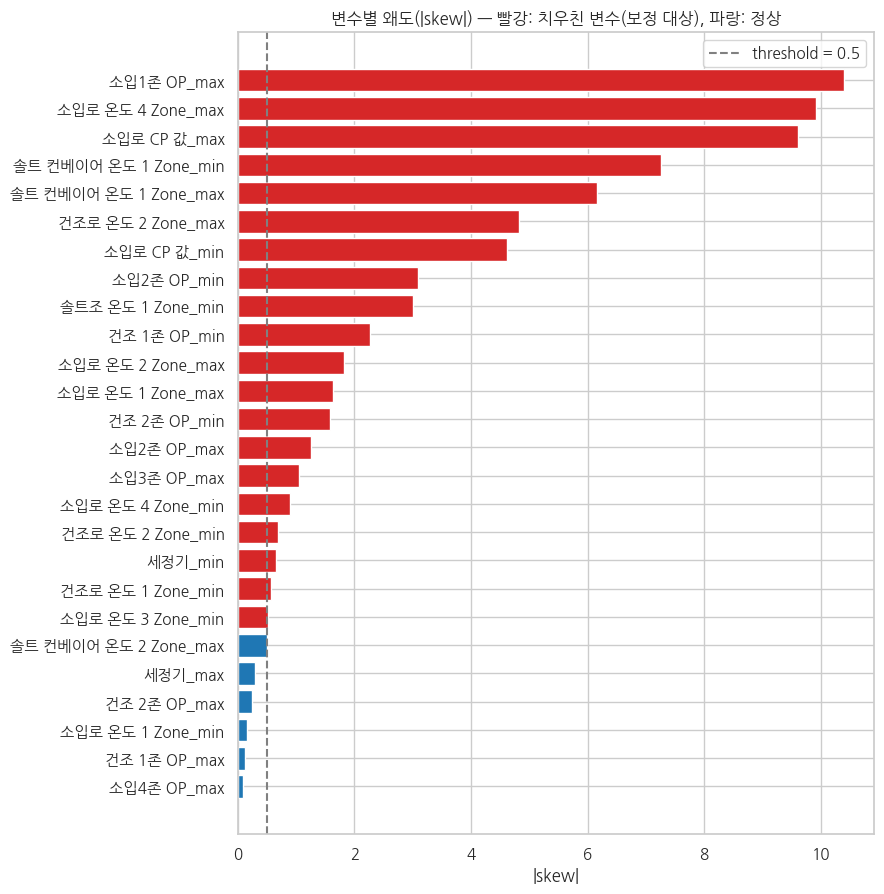

In [9]:
# ===== 8-1. 왜도 계산 (|skew| > 0.5 이면 '치우친 변수') =====
skew_df = tu.check_skewness(X_train, threshold=0.5)
display(skew_df)

n_skewed = int(skew_df["is_skewed"].sum())
print(f"\n치우친(|skew| > 0.5) 변수: {n_skewed}개 / 전체 {len(skew_df)}개")

# 전체 변수의 |skew| 크기를 한눈에 보는 막대그래프
fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(skew_df))))
colors = ["#d62728" if s else "#1f77b4" for s in skew_df["is_skewed"]]
ax.barh(skew_df["column"][::-1], skew_df["abs_skew"][::-1], color=colors[::-1])
ax.axvline(0.5, color="gray", linestyle="--", label="threshold = 0.5")
ax.set_xlabel("|skew|")
ax.set_title("변수별 왜도(|skew|) — 빨강: 치우친 변수(보정 대상), 파랑: 정상")
ax.legend()
fig.tight_layout()
plt.show()


## 9. Yeo-Johnson 파워변환으로 치우친 변수 보정

**왜 Yeo-Johnson인가?** 흔히 쓰는 로그변환(log1p)은 값이 0 이하일 때 적용할 수 없다.
이 데이터는 0에 가깝거나(OP 값 등) 이론상 0 이하 값도 나올 수 있는 센서 집계값이
섞여 있어, 0/음수에서도 안전하게 동작하는 **Yeo-Johnson 파워변환**(`sklearn.preprocessing.
PowerTransformer(method="yeo-johnson")`)을 선택했다. Box-Cox의 확장판으로, 변수마다
최적의 변환 강도(λ)를 데이터로부터 자동으로 찾아 분포를 정규분포에 가깝게 만들어주고,
동시에 평균 0·표준편차 1로 표준화까지 해준다.

**데이터 누수 방지**: 변환 파라미터(λ, 평균/표준편차)는 train에만 `fit`하고, val/test는
그 파라미터로 `transform`만 한다 (01 노트북의 `MinMaxScaler`와 같은 원칙). 치우치지 않은
변수는 건드리지 않고 원본 값을 그대로 둔다.

**"조용한 붕괴(silent collapse)" 가드 (중요)**: scipy 최적화가 예외 없이 끝나더라도,
값이 좁은 양수 범위에 몰려있는 컬럼에서는 λ가 -3~-7 수준의 극단적인 값으로 수렴해,
변환식 `((x+1)^λ - 1) / λ`의 `(x+1)^λ` 항이 수치적으로 0에 언더플로우되는 경우가 있다.
이러면 겉보기엔 "정상적으로 변환"되었지만 실제로는 해당 컬럼의 정보가 전부 사라지고
거의 완전한 상수 컬럼이 되어버린다. 아래 9-1에서는 변환 직후 train 표준편차를 확인해
이런 경우를 "실패"로 분류하고 원본값을 유지하는 가드를 적용한다 (자세한 수치 증거는
9-1-A 참고).

In [10]:
# ===== 9-1. 치우친 변수에만 Yeo-Johnson 파워변환 적용 (train에만 fit) =====
# 컬럼별로 하나씩 개별 fit 하기 때문에, 특정 컬럼(예: 값이 0 근처에 몰려있거나
# 표본이 적어 최적화가 불안정한 컬럼)에서 scipy 최적화가 실패해도 그 컬럼만
# 건너뛰고(원본값 유지) 나머지 컬럼은 정상적으로 변환된다.
#
# + (2026-09-16 추가) scipy 최적화가 예외 없이 "성공"하더라도 극단적인 lambda로
#   인해 변환값이 수치적으로 상수에 가깝게 "조용히 붕괴"하는 경우가 있다.
#   correct_skew_with_power_transform() 내부에 변환 후 표준편차를 확인하는
#   가드(collapse_std_threshold=1e-3, 기본값)를 추가해 이런 컬럼도 자동으로
#   감지해 원본값을 유지하도록 했다. 자세한 이유는 함수 docstring 참고.
skewed_cols = skew_df.loc[skew_df["is_skewed"], "column"].tolist()
print(f"Yeo-Johnson 파워변환을 적용할 변수 {len(skewed_cols)}개:")
for c in skewed_cols:
    print(" -", c)

result = tu.correct_skew_with_power_transform(X_train, X_val, X_test, skewed_cols, method="yeo-johnson")
X_train_transformed = result["X_train"]
X_val_transformed = result["X_val"]
X_test_transformed = result["X_test"]
power_transformer = result["transformer"]              # {컬럼명: PowerTransformer} 딕셔너리
transformed_columns = result["transformed_columns"]     # 실제로 변환된 컬럼
failed_columns = result["failed_columns"]               # 최적화 실패 또는 붕괴로 원본값 유지된 컬럼
skew_before_after = result["skew_before_after"]

print(f"\n변환 성공: {len(transformed_columns)}개 / 원본값 유지(실패 또는 붕괴): {len(failed_columns)}개")
print("\n=== 변환 전/후 skew 비교 (성공한 컬럼만) ===")
display(skew_before_after)

Yeo-Johnson 파워변환을 적용할 변수 20개:
 - 소입1존 OP_max
 - 소입로 온도 4 Zone_max
 - 소입로 CP 값_max
 - 솔트 컨베이어 온도 1 Zone_min
 - 솔트 컨베이어 온도 1 Zone_max
 - 건조로 온도 2 Zone_max
 - 소입로 CP 값_min
 - 소입2존 OP_min
 - 솔트조 온도 1 Zone_min
 - 건조 1존 OP_min
 - 소입로 온도 2 Zone_max
 - 소입로 온도 1 Zone_max
 - 건조 2존 OP_min
 - 소입2존 OP_max
 - 소입3존 OP_max
 - 소입로 온도 4 Zone_min
 - 건조로 온도 2 Zone_min
 - 세정기_min
 - 건조로 온도 1 Zone_min
 - 소입로 온도 3 Zone_min
[경고] 7개 변수는 원본 값을 그대로 둡니다:
  - 소입로 온도 4 Zone_max: CollapsedTransform: lambda=-4.2167 로 변환 후 train std=9.249e-16 (<1e-03) -> 수치적으로 상수에 가깝게 붕괴, 원본값 유지
  - 솔트 컨베이어 온도 1 Zone_min: CollapsedTransform: lambda=-5.2825 로 변환 후 train std=6.367e-16 (<1e-03) -> 수치적으로 상수에 가깝게 붕괴, 원본값 유지
  - 솔트조 온도 1 Zone_min: BracketError: The algorithm terminated without finding a valid bracket. Consider trying different initial points.
  - 소입로 온도 2 Zone_max: CollapsedTransform: lambda=-3.8180 로 변환 후 train std=4.464e-15 (<1e-03) -> 수치적으로 상수에 가깝게 붕괴, 원본값 유지
  - 소입로 온도 4 Zone_min: CollapsedTransform: lambda=-3.6656 로 변환

,column,skew_before,skew_after,abs_skew_before,abs_skew_after
0,소입1존 OP_max,-10.392305,-10.392305,10.392305,10.392305
1,소입로 CP 값_max,9.613812,0.317371,9.613812,0.317371
2,솔트 컨베이어 온도 1 Zone_max,-6.154958,-1.810778,6.154958,1.810778
3,건조로 온도 2 Zone_max,-4.816178,-1.822899,4.816178,1.822899
4,소입로 CP 값_min,-4.617347,-1.232087,4.617347,1.232087
5,소입2존 OP_min,-3.097132,0.128388,3.097132,0.128388
6,건조 1존 OP_min,2.268558,-0.085909,2.268558,0.085909
7,소입로 온도 1 Zone_max,-1.626353,-0.925370,1.626353,0.925370
8,건조 2존 OP_min,1.577293,0.127217,1.577293,0.127217
9,소입2존 OP_max,-1.255138,0.093196,1.255138,0.093196


### 9-1-A. (증거) 붕괴 가드가 없었다면 어떤 일이 벌어졌을까?

가드를 적용하지 않고 모든 치우친 변수를 그대로 변환했다고 가정했을 때와,
가드를 적용해 붕괴된 컬럼을 원본값으로 유지한 지금 상태를 설계행렬
(`X_train` + 절편항)의 **조건수(condition number)**로 비교한다. 조건수가
1e10 이상이면 수치적으로 거의 특이행렬(singular matrix)에 가까워
LinearRegression 계수가 폭주할 수 있다.

In [11]:
# ===== 9-1-A. 가드 적용 전/후 조건수(condition number) 비교 (증거) =====
import numpy as np

def _design_matrix_condition_number(X_df):
    """주어진 피처 DataFrame에 절편(상수 1) 컬럼을 추가한 설계행렬의
    조건수(condition number, 최대특이값/최소특이값)를 계산한다.
    조건수가 클수록 설계행렬이 수치적으로 특이행렬에 가까워
    회귀 계수 추정이 불안정해진다(계수 폭주의 직접적 원인이 될 수 있음).
    """
    design = np.column_stack([np.ones(len(X_df)), X_df.values])
    return float(np.linalg.cond(design))

# (a) 가드를 적용하지 않았다면: 붕괴된 컬럼도 "변환된" 값을 그대로 사용
X_train_no_guard = X_train_transformed.copy()

# 가드에 걸린(=붕괴된) 컬럼만 골라, 가드가 없었다면 어떤 값이 저장됐을지 재현
from sklearn.preprocessing import PowerTransformer

collapsed_cols_demo = [c for c, msg in failed_columns if msg.startswith("CollapsedTransform")]
for col in collapsed_cols_demo:
    pt_demo = PowerTransformer(method="yeo-johnson", standardize=True)
    pt_demo.fit(X_train[[col]])
    X_train_no_guard[col] = pt_demo.transform(X_train[[col]])

cond_before_guard = _design_matrix_condition_number(X_train_no_guard)
cond_after_guard = _design_matrix_condition_number(X_train_transformed)

print(f"붕괴 가드로 원본값을 유지한 컬럼: {len(collapsed_cols_demo)}개 {collapsed_cols_demo}")
print()
print(f"[가드 미적용 가정] 설계행렬 조건수: {cond_before_guard:.3e}  "
      f"{'<- 1e10 이상, 사실상 특이행렬' if cond_before_guard >= 1e10 else ''}")
print(f"[가드 적용(현재)]   설계행렬 조건수: {cond_after_guard:.3e}  "
      f"{'<- 정상 범위' if cond_after_guard < 1e4 else ''}")

붕괴 가드로 원본값을 유지한 컬럼: 6개 ['소입로 온도 4 Zone_max', '솔트 컨베이어 온도 1 Zone_min', '소입로 온도 2 Zone_max', '소입로 온도 4 Zone_min', '건조로 온도 2 Zone_min', '건조로 온도 1 Zone_min']

[가드 미적용 가정] 설계행렬 조건수: 7.280e+18  <- 1e10 이상, 사실상 특이행렬
[가드 적용(현재)]   설계행렬 조건수: 1.266e+07  


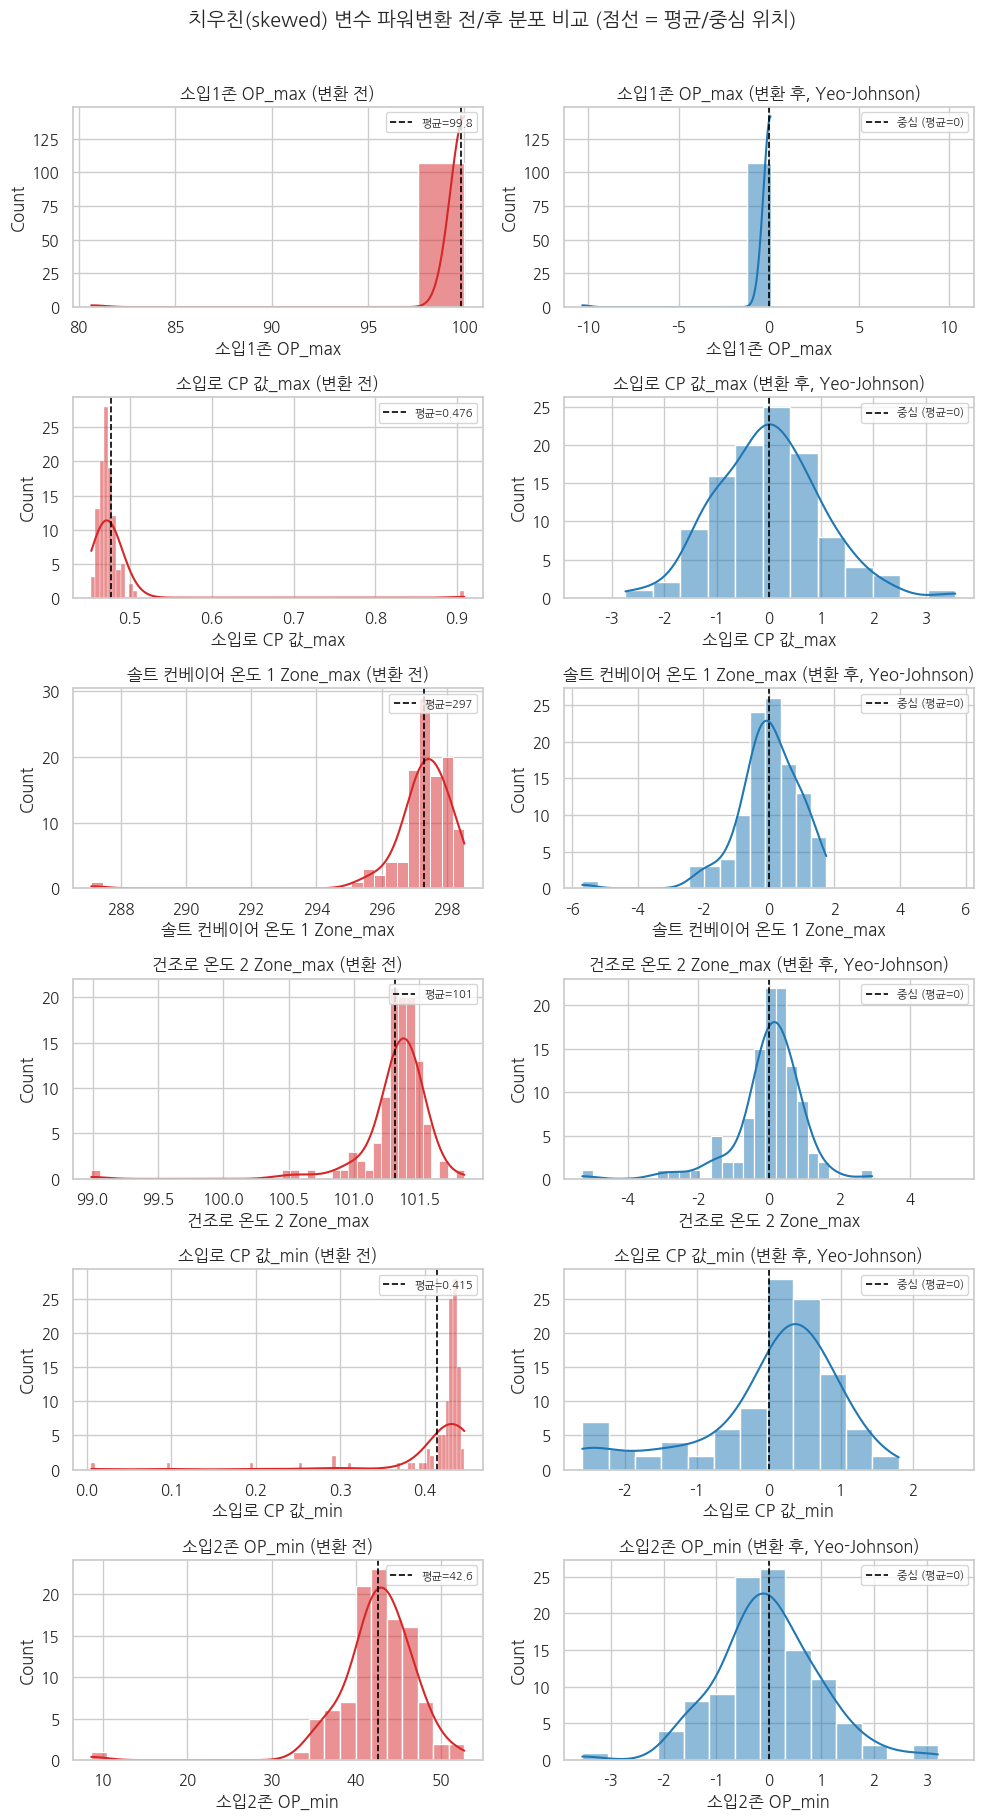

In [12]:
# ===== 9-2. 변환 전/후 분포 비교 (상위 6개 변수) =====
# 실제로 변환이 성공한 컬럼(transformed_columns)만 그린다. skewed_cols 전체를 그리면
# 변환에 실패해 원본 그대로인 컬럼까지 '전/후가 똑같은' 그래프로 나와 헷갈리기 때문.
fig = tu.plot_skew_before_after(X_train, X_train_transformed, transformed_columns, top_n=6)
if fig is not None:
    fig.savefig(os.path.join(FIGURE_DIR, "12_skew_before_after.png"), dpi=150)
    plt.show()
else:
    print("변환에 성공한 변수가 없어 시각화를 건너뜁니다.")


## 10. 결과 저장 (다음 노트북에서 그대로 재사용)

In [13]:
# ===== 10-1. 왜도 보정된 train/val/test 와 y, 변환기(transformer) 저장 =====
print("결과 저장 중 ...")

X_train_transformed.to_csv(os.path.join(PROCESSED_DIR, "X_train_skew_corrected.csv"),
                            index=True, encoding="utf-8-sig")
X_val_transformed.to_csv(os.path.join(PROCESSED_DIR, "X_val_skew_corrected.csv"),
                          index=True, encoding="utf-8-sig")
X_test_transformed.to_csv(os.path.join(PROCESSED_DIR, "X_test_skew_corrected_DO_NOT_OPEN.csv"),
                           index=True, encoding="utf-8-sig")
print("  -> X_train/X_val/X_test (skew 보정본) 저장 완료 (data_processed/)")

# y는 01에서 저장하지 않았으므로, 03 노트북에서 다시 분할할 필요 없도록 여기서 함께 저장해 둔다.
y_train.to_csv(os.path.join(PROCESSED_DIR, "y_train.csv"), index=True, encoding="utf-8-sig")
y_val.to_csv(os.path.join(PROCESSED_DIR, "y_val.csv"), index=True, encoding="utf-8-sig")
y_test.to_csv(os.path.join(PROCESSED_DIR, "y_test_DO_NOT_OPEN.csv"), index=True, encoding="utf-8-sig")
print("  -> y_train/y_val/y_test 저장 완료 (data_processed/)")

if power_transformer:  # 딕셔너리이므로 비어있지 않을 때만 저장 (변환 성공한 컬럼이 하나도 없으면 빈 dict)
    pt_path = os.path.join(CHECKPOINT_DIR, "power_transformer.joblib")
    joblib.dump(power_transformer, pt_path)
    print(f"  -> Yeo-Johnson PowerTransformer(컬럼별 딕셔너리, {len(power_transformer)}개) 저장 완료: {pt_path}")
else:
    print("  -> 변환에 성공한 컬럼이 없어 PowerTransformer는 저장하지 않았습니다.")

if failed_columns:
    print(f"  -> 참고: {len(failed_columns)}개 컬럼은 Yeo-Johnson 변환 실패로 원본값을 그대로 저장했습니다: "
          f"{[c for c, _ in failed_columns]}")

original_row_range.to_csv(index_ref_path, index=False, encoding="utf-8-sig")  # 2-1에서 이미 저장했지만 재확인 차 재저장
print(f"  -> 원본 행 번호 참조 파일: {index_ref_path}")

print("\n모든 산출물 저장 완료.")


결과 저장 중 ...
  -> X_train/X_val/X_test (skew 보정본) 저장 완료 (data_processed/)
  -> y_train/y_val/y_test 저장 완료 (data_processed/)
  -> Yeo-Johnson PowerTransformer(컬럼별 딕셔너리, 13개) 저장 완료: ..\checkpoints\power_transformer.joblib
  -> 참고: 7개 컬럼은 Yeo-Johnson 변환 실패로 원본값을 그대로 저장했습니다: ['소입로 온도 4 Zone_max', '솔트 컨베이어 온도 1 Zone_min', '솔트조 온도 1 Zone_min', '소입로 온도 2 Zone_max', '소입로 온도 4 Zone_min', '건조로 온도 2 Zone_min', '건조로 온도 1 Zone_min']
  -> 원본 행 번호 참조 파일: ..\data_processed\original_row_range.csv

모든 산출물 저장 완료.


## 11. 결론 및 다음 단계

- **Unnamed 처리**: `Unnamed: 0`(원본 CSV 행 번호)이 실수로 01의 모델 입력 변수
  (`Unnamed: 0_max`)에 포함돼 있던 문제를 해결했다. 배정번호별 원본 행 범위는
  `data_processed/original_row_range.csv`에 따로 보관하고, 분석/모델링용 데이터에서는
  완전히 제외했다.
- **독립변수 개수 변화**: Unnamed 2개 컬럼 제외로 38개 → 36개 → 다중공선성 제거 후
  `X_reduced.shape[1]`개 (위 5단계 출력 참고, 01에서는 27개였음).
- **왜도 보정**: `X_train` 기준 왜도를 진단해 치우친 변수에는 Yeo-Johnson 파워변환을
  적용했다 (train에만 fit, val/test는 transform만 적용해 누수 방지).
- **"조용한 붕괴" 가드 추가 (2026-09-16)**: 일부 컬럼에서 scipy 최적화가 예외 없이
  성공하고도 극단적인 λ로 인해 변환값이 수치적으로 상수에 가깝게 붕괴하는 문제를
  발견해, 변환 후 표준편차 기반 가드를 추가했다. 이 가드에 걸린 컬럼은 원본값을
  그대로 사용한다 (구체적으로 몇 개/어떤 컬럼이 걸렸는지는 위 9-1 출력 참고 —
  실행 환경의 scipy/sklearn 버전에 따라 최적화 결과가 미세하게 달라질 수 있어
  컬럼 목록이 실행마다 완전히 동일하지 않을 수 있다). 9-1-A에서 이 가드가 없었다면
  설계행렬 조건수가 어떻게 악화되는지 수치로 확인했다.
- **저장된 파일**: `original_row_range.csv`, `X_train_skew_corrected.csv` /
  `X_val_skew_corrected.csv` / `X_test_skew_corrected_DO_NOT_OPEN.csv`,
  `y_train.csv` / `y_val.csv` / `y_test_DO_NOT_OPEN.csv`,
  `checkpoints/power_transformer.joblib`, 그림 3장(`10_`, `11_`, `12_`).

### 다음 단계 (03 노트북 예정)

- 이 노트북이 저장한 `*_skew_corrected.csv`와 `y_*.csv`를 불러와 LinearRegression /
  SGDRegressor(체크포인트 재개 포함)를 다시 학습하고, 01의 결과(Test R²=0.0414)와
  비교한다.
- Ridge/Lasso 등 정규화 회귀, 트리 계열 모델과의 비교도 이어서 검토한다.

> **참고**: 이번 수정 이전에 `03_model_comparison.ipynb`(1차 보고서 근거)와
> `04_advanced_modeling.ipynb`(2차 보고서 근거)는 이미 실행되어 각자의 시점 데이터
> 기준으로 결과가 보고서에 기록되어 있으므로, 이 두 노트북은 재실행하지 않고
> 과거 실행 결과를 그대로 보존한다. 이번에 고친 전처리를 반영한 재학습/재검증은
> `05_improved_modeling.ipynb`에서 새로 진행한다.